In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("paper")

In [5]:
import pandas as pd

df = pd.read_csv("../../../datasets/nurse/raw/nurse_no_features.csv", low_memory=False)

In [7]:
df.head()

,X,Y,Z,EDA,HR,TEMP,id,datetime,label
0,-13.0,-61.0,5.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.000000000,2.0
1,-20.0,-69.0,-3.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.031249920,2.0
2,-31.0,-78.0,-15.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.062500096,2.0
3,-47.0,-65.0,-38.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.093750016,2.0
4,-67.0,-57.0,-53.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.124999936,2.0


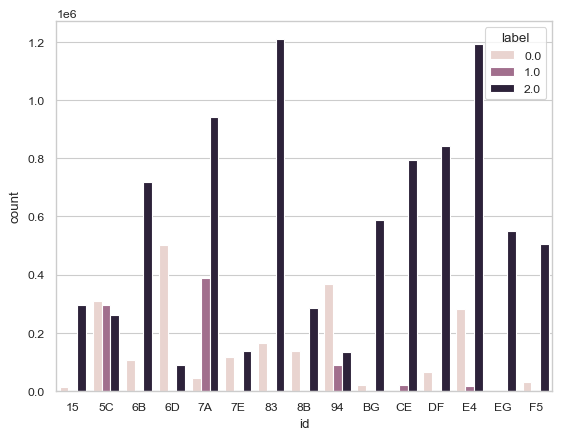

In [6]:
sns.countplot(x=df["id"], hue=df["label"])
plt.show()

In [9]:
from pymongo.synchronous.collection import Collection
from pymongo import MongoClient

client = MongoClient("localhost", 27017)
db = client["paper_2"]
collection: Collection = db["federated"]

In [10]:
document = collection.find_one({"_id": "3ad9ccd1ad3714636bb77a2b618f5fcfed3e96bc27d7ea8f686404eb9fff5bc1"})

In [11]:
run = document["training_runs"][0]
clients = run["clients"]
server = clients["server"]
del clients["server"]

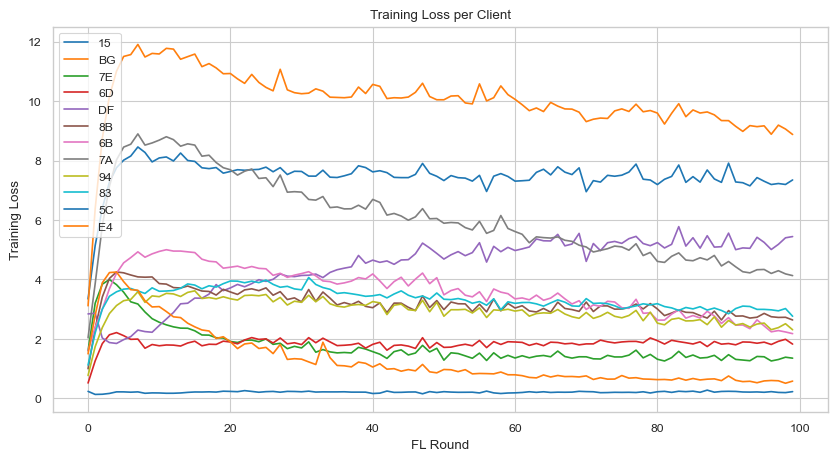

In [21]:
# Create figure once before the loop
plt.figure(figsize=(10, 5))

for client_name, client_data in clients.items():
    training_loss = [data["scores"]["training_set"]["loss"] for data in client_data["round"].values()]
    sns.lineplot(training_loss, label=client_name)

plt.xlabel("FL Round")
plt.ylabel("Training Loss")
plt.title("Training Loss per Client")
plt.legend()
plt.show()

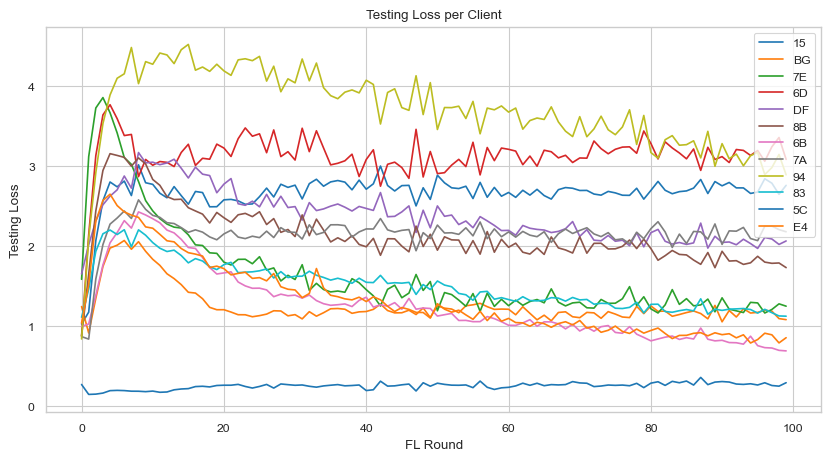

In [22]:
from matplotlib import pyplot as plt

# Create figure once before the loop
plt.figure(figsize=(10, 5))

for client_name, client_data in clients.items():
    testing_loss = [data["scores"]["testing_set"]["loss"] for data in client_data["round"].values()]
    sns.lineplot(testing_loss, label=client_name)

plt.xlabel("FL Round")
plt.ylabel("Testing Loss")
plt.title("Testing Loss per Client")
plt.legend()
plt.show()

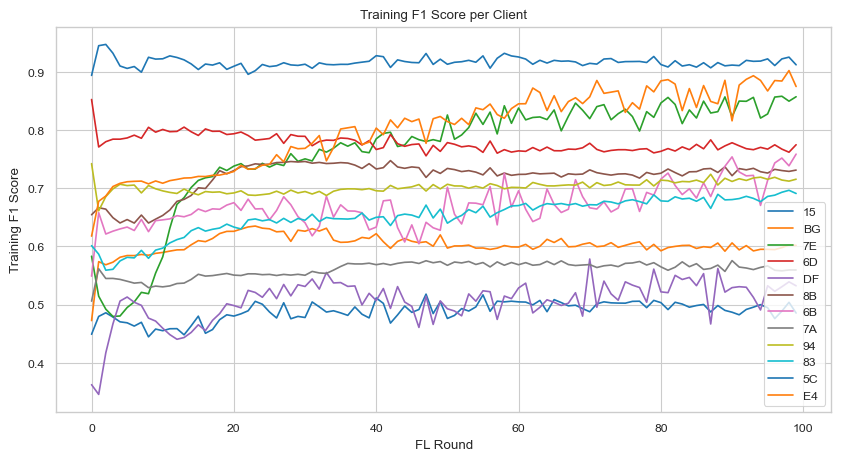

In [23]:
from matplotlib import pyplot as plt

# Create figure once before the loop
plt.figure(figsize=(10, 5))

for client_name, client_data in clients.items():
    training_f1 = [data["scores"]["training_set"]["f1"] for data in client_data["round"].values()]
    sns.lineplot(training_f1, label=client_name)

plt.xlabel("FL Round")
plt.ylabel("Training F1 Score")
plt.title("Training F1 Score per Client")
plt.legend()
plt.show()

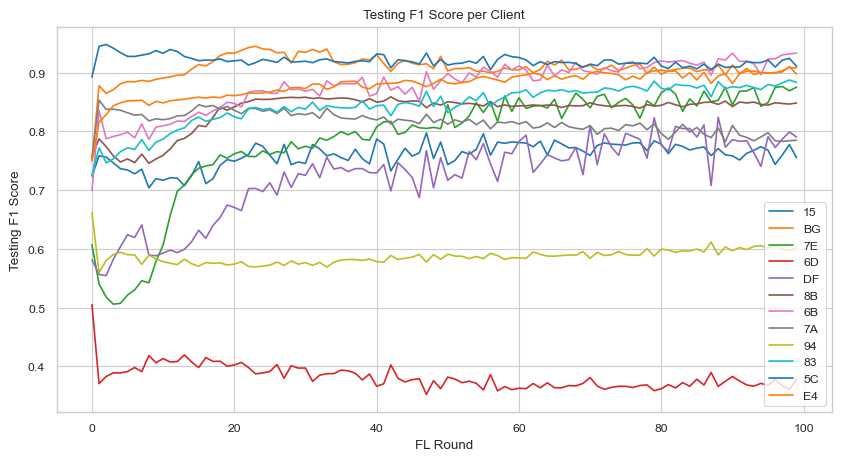

In [24]:
from matplotlib import pyplot as plt

# Create figure once before the loop
plt.figure(figsize=(10, 5))

for client_name, client_data in clients.items():
    testing_f1 = [data["scores"]["testing_set"]["f1"] for data in client_data["round"].values()]
    sns.lineplot(testing_f1, label=client_name)

plt.xlabel("FL Round")
plt.ylabel("Testing F1 Score")
plt.title("Testing F1 Score per Client")
plt.legend()
plt.show()

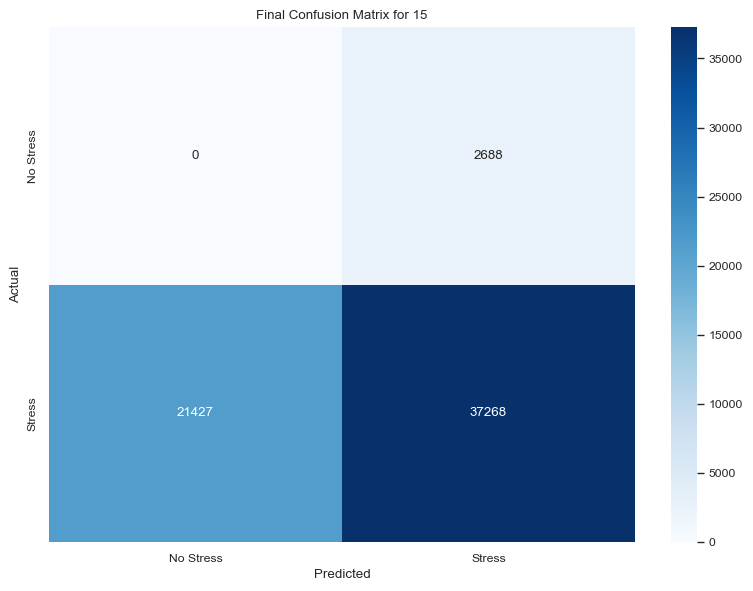

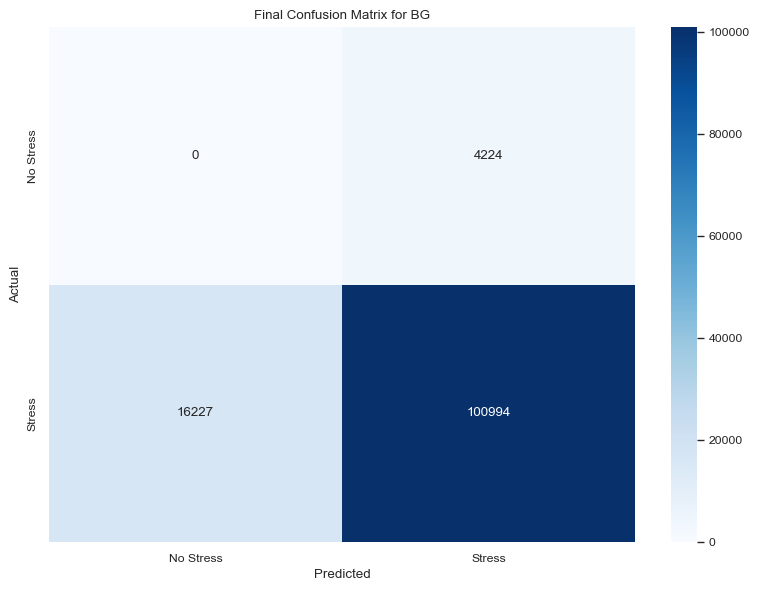

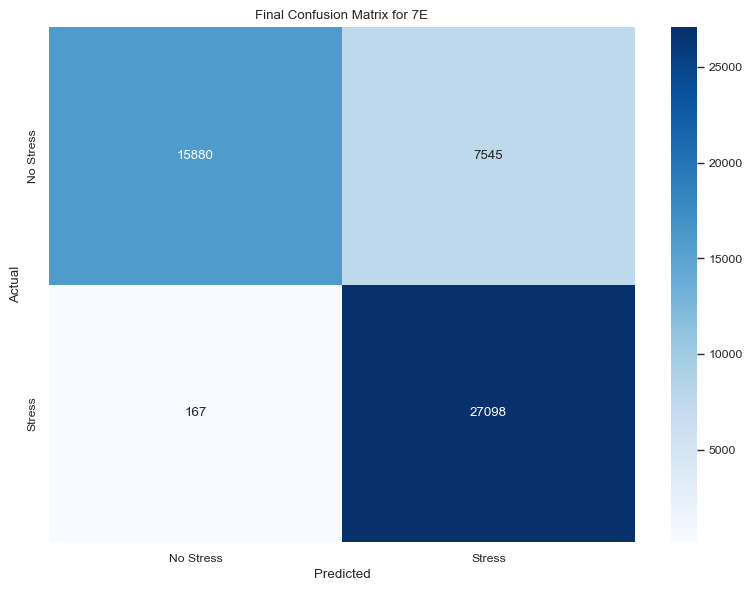

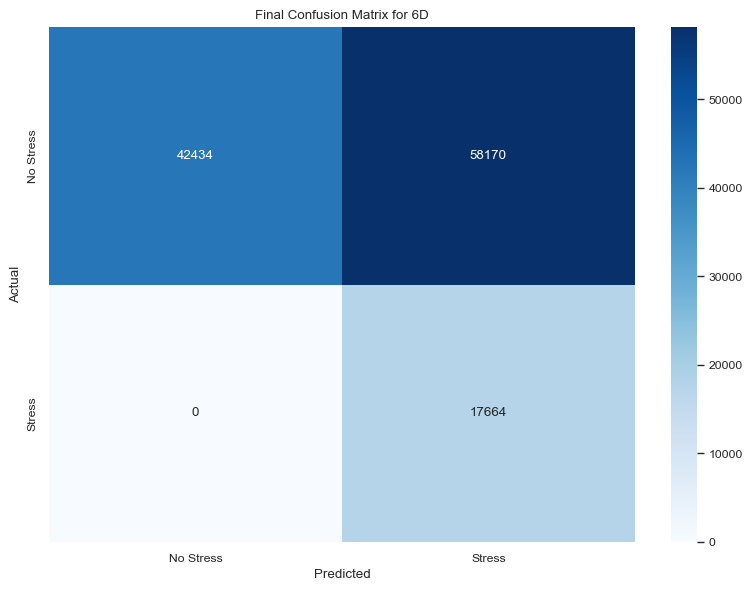

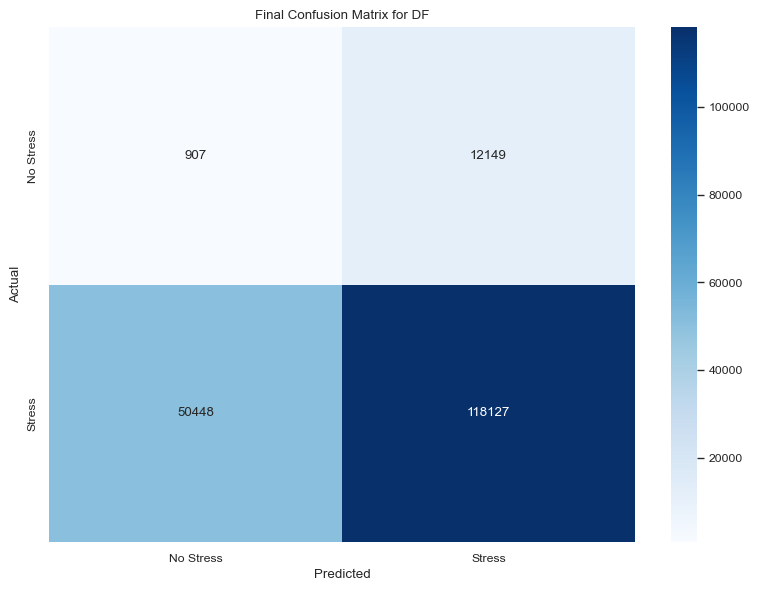

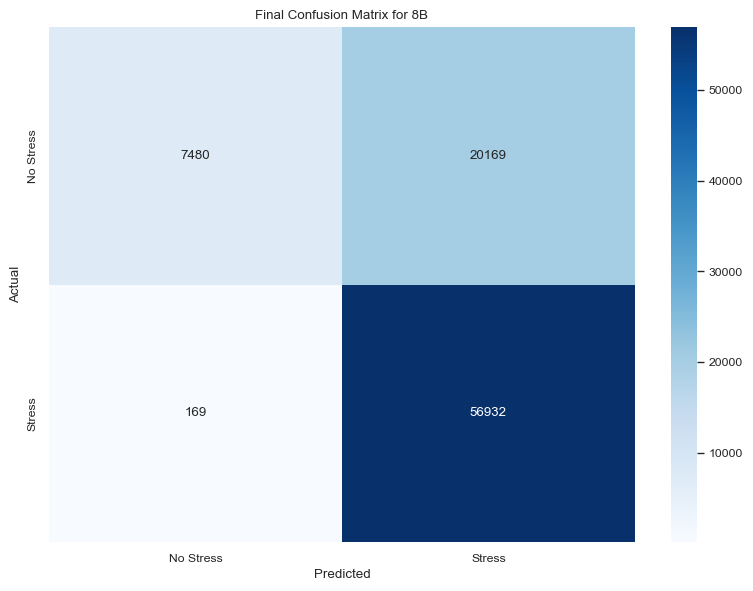

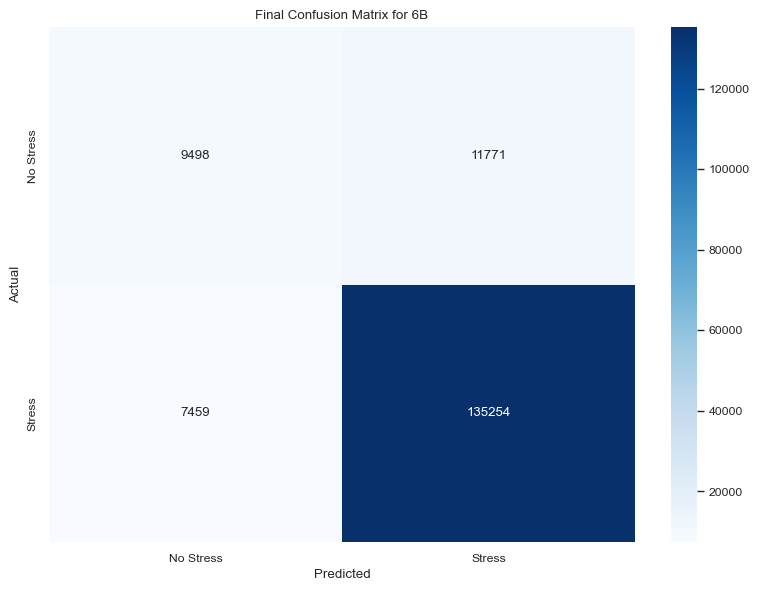

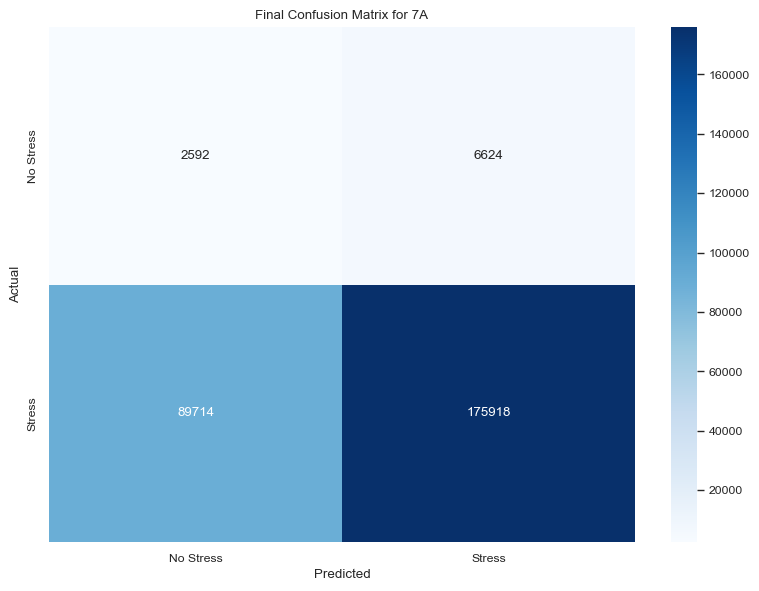

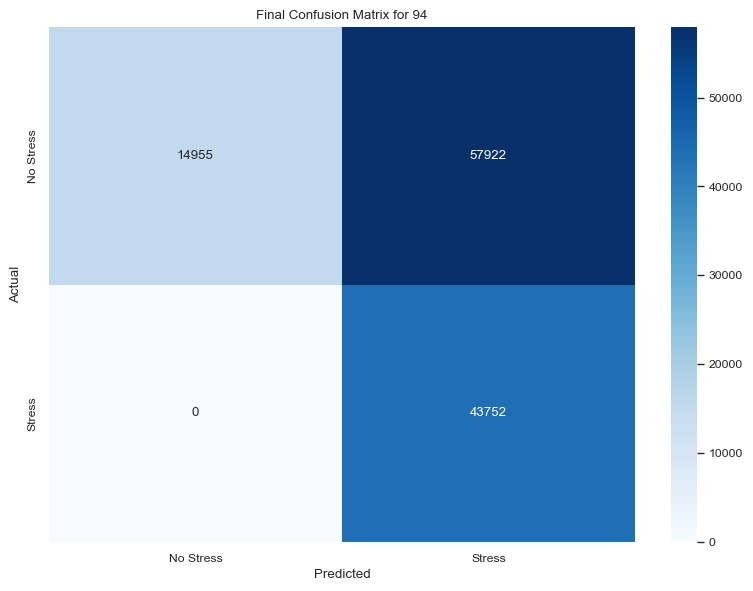

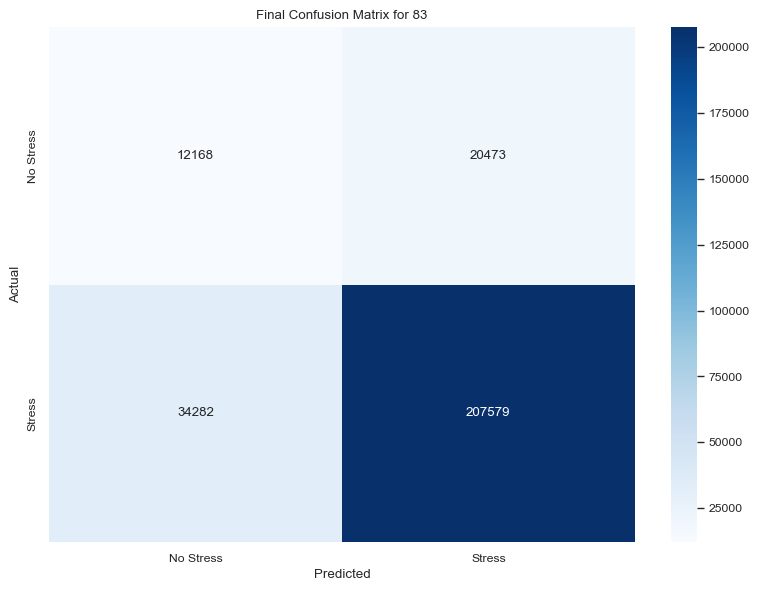

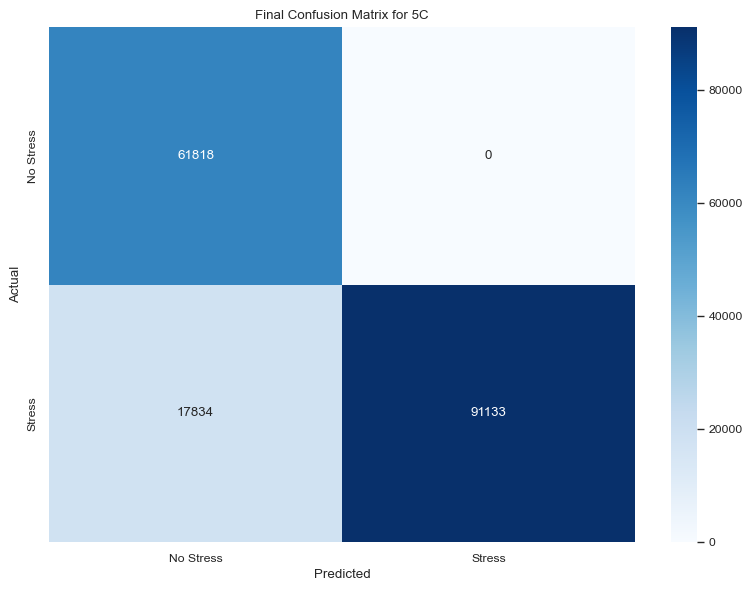

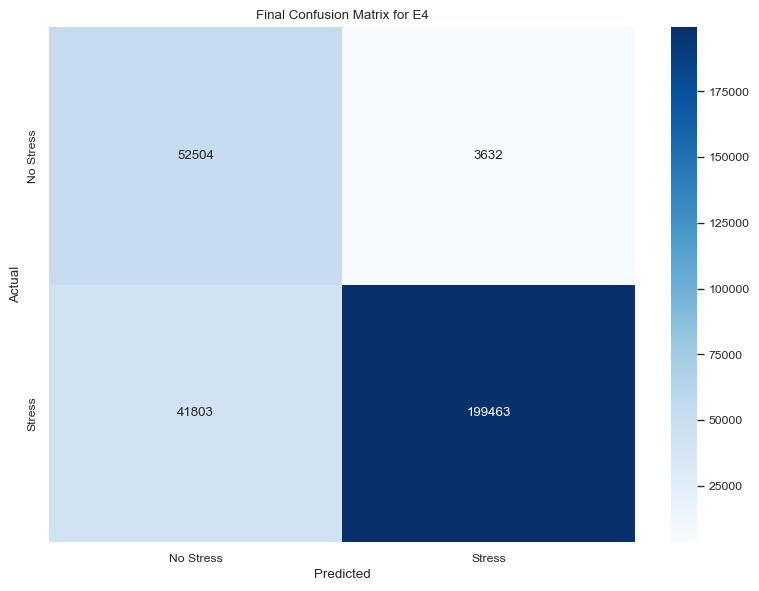

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

for client_name, client_data in clients.items():
    matrix = client_data["round"]["100"]["scores"]["testing_set"]["confusion_matrix"]
    # Assemble the confusion matrix from tp, tn, fp, fn
    conf_matrix = np.array([
        [matrix["tn"], matrix["fp"]],  # First row: actual negatives
        [matrix["fn"], matrix["tp"]]   # Second row: actual positives
    ])

    labels = ["No Stress", "Stress"]  # You can replace with your actual class names

    # Alternative with seaborn for more customization
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Final Confusion Matrix for ' + client_name)
    plt.tight_layout()
    plt.show()

## Server Side

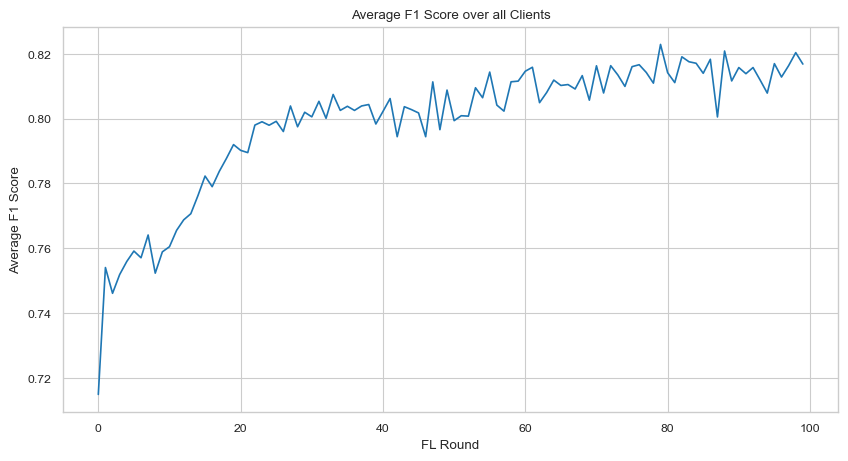

In [25]:
from matplotlib import pyplot as plt

# Create figure once before the loop
plt.figure(figsize=(10, 5))

server_data = server["distributed"]
average_f1 = [score["scores"] for score in server_data["round"].values()]
sns.lineplot(average_f1)
plt.xlabel("FL Round")
plt.ylabel("Average F1 Score")
plt.title("Average F1 Score over all Clients")
plt.show()

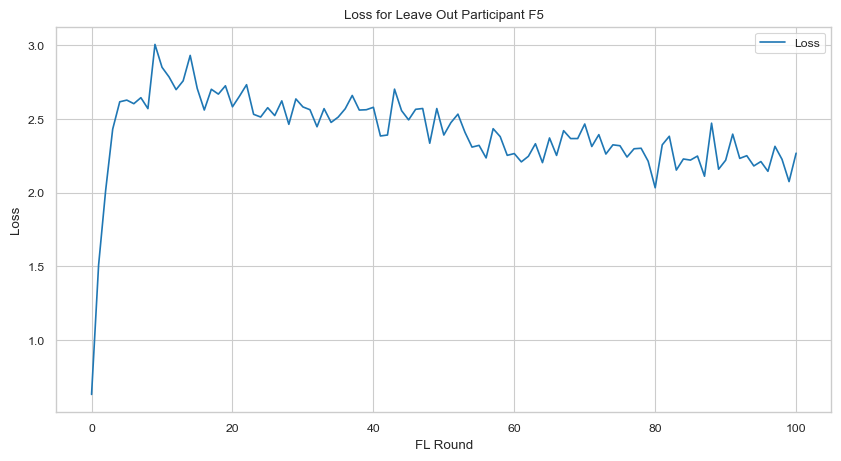

In [26]:
from matplotlib import pyplot as plt

# Create figure once before the loop
plt.figure(figsize=(10, 5))

server_data = server["centralized"]
loss = [score["scores"]["testing_set"]["loss"] for score in server_data["round"].values()]
sns.lineplot(loss, label="Loss")
plt.xlabel("FL Round")
plt.ylabel("Loss")
plt.title("Loss for Leave Out Participant F5")
plt.legend()
plt.show()

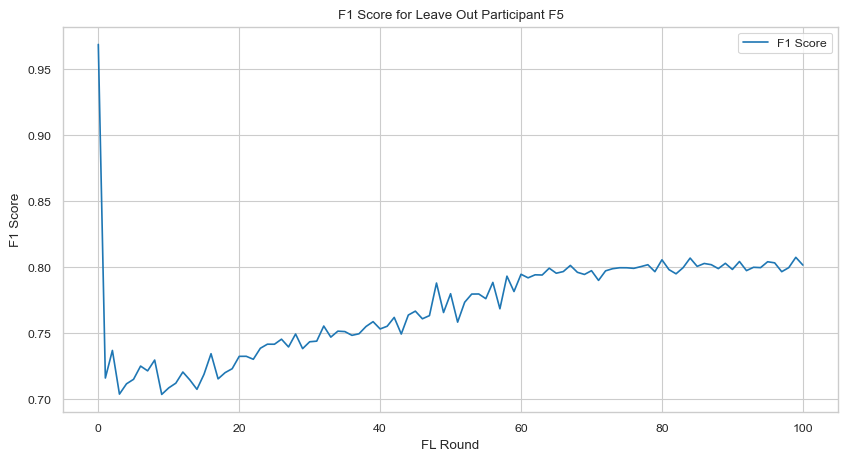

In [27]:
from matplotlib import pyplot as plt

# Create figure once before the loop
plt.figure(figsize=(10, 5))

server_data = server["centralized"]
f1 = [score["scores"]["testing_set"]["f1"] for score in server_data["round"].values()]
sns.lineplot(f1, label="F1 Score")
plt.xlabel("FL Round")
plt.ylabel("F1 Score")
plt.title("F1 Score for Leave Out Participant F5")
plt.legend()
plt.show()

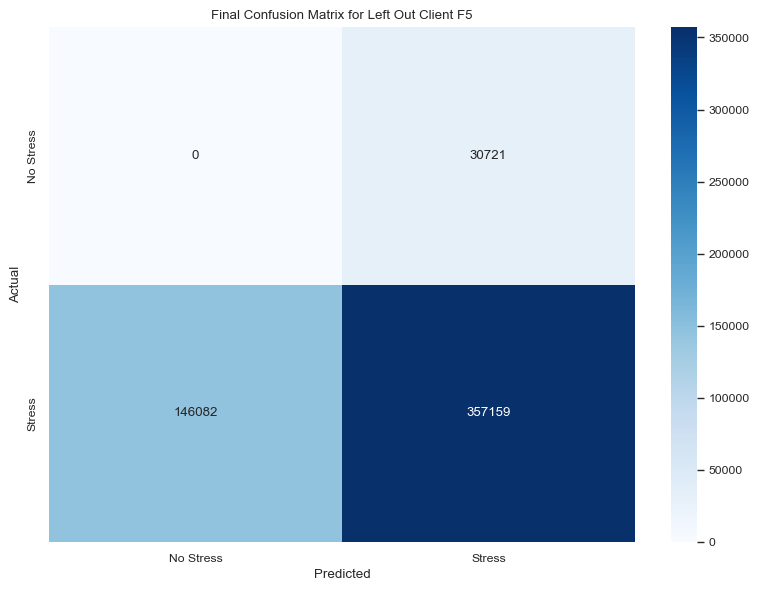

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

matrix = server["centralized"]["round"]["100"]["scores"]["testing_set"]["confusion_matrix"]
# Assemble the confusion matrix from tp, tn, fp, fn
conf_matrix = np.array([
    [matrix["tn"], matrix["fp"]],  # First row: actual negatives
    [matrix["fn"], matrix["tp"]]   # Second row: actual positives
])

# Plot the confusion matrix
labels = ["No Stress", "Stress"]  # You can replace with your actual class names

# Alternative with seaborn for more customization
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Final Confusion Matrix for Left Out Client F5')
plt.tight_layout()
plt.show()